In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('updated3.csv')

print("Dataset Overview:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nTarget variable distribution:")
print(df['muscle_size_increase_cm2'].describe())



Dataset Overview:
   age gender exercise_type  sets  reps  weight  frequency  protein  calories  \
0   56      M     Deadlifts     6    15   146.1          4     90.5      2986   
1   46      M     Deadlifts     3    13   155.6          5    192.4      2794   
2   32      F        Squats     6     8   177.1          1    179.1      2245   
3   25      M        Squats     6     7   110.0          1    175.0      2057   
4   38      M     Deadlifts     5    11   151.4          5    104.1      3611   

   sleep    experience  muscle_size_increase_cm2 target_muscle_group  \
0    5.2      Advanced                      1.84                Back   
1    9.4  Intermediate                      4.61                Back   
2    5.1  Intermediate                      4.72               Quads   
3    9.7  Intermediate                      3.21               Quads   
4    7.4  Intermediate                      5.27                Back   

  exercise_category  
0          Compound  
1          Compoun

In [2]:
# Define baseline muscle growth equation parameters with current size and diminishing returns
def get_baseline_params(age, gender, experience, current_size_cm, workout_time_years):
    """Get baseline parameters for muscle growth equation with diminishing returns"""
    
    # Genetic limit (M_max) - simplified based on gender and age
    if gender == 'M':
        base_limit = 45  # pounds of potential muscle gain
        age_factor = max(0.7, 1 - (age - 25) * 0.01)  # decline after 25
    else:  # Female
        base_limit = 30  # pounds of potential muscle gain  
        age_factor = max(0.7, 1 - (age - 25) * 0.008)
    
    M_max = base_limit * age_factor
    
    # Adjust M_max based on current size (diminishing returns)
    remaining_potential = max(0, M_max - (current_size_cm * 0.2))  # Convert cm to rough lb equivalent
    
    # Growth rate constant (k) based on experience and workout time
    k_base = {
        'Beginner': 0.20,
        'Intermediate': 0.10, 
        'Advanced': 0.05
    }
    k = k_base.get(experience, 0.10) * (1 / (1 + workout_time_years * 0.1))  # Diminishing rate with time
    
    return remaining_potential, k

def calculate_baseline_growth(row, time_months=3, current_size_cm=0, workout_time_years=0):
    """Calculate baseline muscle growth using the equation with current size"""
    M_max, k = get_baseline_params(row['age'], row['gender'], row['experience'], current_size_cm, workout_time_years)
    
    # Starting muscle size (M0) - use current size as starting point
    M0 = current_size_cm * 0.2  # Convert cm to rough lb equivalent
    
    # Baseline growth equation: M(t) = M0 + (M_max - M0)(1 - e^(-kt))
    baseline_growth = (M_max - M0) * (1 - np.exp(-k * time_months))
    
    # Convert to cm2 approximation
    baseline_cm2 = baseline_growth * 5  # Adjusted scaling factor for realism
    
    return baseline_cm2

# Calculate baseline growth for each row (assuming no initial size for training data)
df['baseline_growth'] = df.apply(calculate_baseline_growth, axis=1)

# Calculate adjustment factor
df['adjustment_factor'] = df['muscle_size_increase_cm2'] / df['baseline_growth']

print("\nBaseline vs Actual Growth:")
print(f"Mean baseline growth: {df['baseline_growth'].mean():.2f} cm2")
print(f"Mean actual growth: {df['muscle_size_increase_cm2'].mean():.2f} cm2")
print(f"Mean adjustment factor: {df['adjustment_factor'].mean():.2f}")

# Feature engineering
le_gender = LabelEncoder()
le_exercise = LabelEncoder()
le_experience = LabelEncoder()
le_muscle_group = LabelEncoder()
le_category = LabelEncoder()

df['gender_encoded'] = le_gender.fit_transform(df['gender'])
df['exercise_type_encoded'] = le_exercise.fit_transform(df['exercise_type'])
df['experience_encoded'] = le_experience.fit_transform(df['experience'])
df['muscle_group_encoded'] = le_muscle_group.fit_transform(df['target_muscle_group'])
df['category_encoded'] = le_category.fit_transform(df['exercise_category'])

# Create additional features
df['protein_per_kg'] = df['protein'] / (df['weight'] * 0.45)
df['volume'] = df['sets'] * df['reps']
df['intensity'] = df['weight'] / df['reps']
df['calories_per_kg'] = df['calories'] / (df['weight'] * 0.45)

# Select features for ML model
features = [
    'age', 'gender_encoded', 'exercise_type_encoded', 'sets', 'reps', 'weight',
    'frequency', 'protein', 'calories', 'sleep', 'experience_encoded',
    'muscle_group_encoded', 'category_encoded', 'protein_per_kg', 'volume',
    'intensity', 'calories_per_kg'
]

X = df[features]
y = df['adjustment_factor']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))



Baseline vs Actual Growth:
Mean baseline growth: 48.22 cm2
Mean actual growth: 4.84 cm2
Mean adjustment factor: 0.10

Model Performance:
Mean Squared Error: 0.0019
R² Score: -3.6242

Top 10 Most Important Features:
                  feature  importance
11   muscle_group_encoded    0.182975
14                 volume    0.145935
15              intensity    0.130240
5                  weight    0.106524
8                calories    0.071690
0                     age    0.054263
1          gender_encoded    0.047178
2   exercise_type_encoded    0.042300
6               frequency    0.039271
9                   sleep    0.038896


In [3]:
# Function to make predictions with current size
def predict_muscle_growth(age, gender, exercise_type, sets, reps, weight,
                          frequency, protein, calories, sleep, experience,
                          target_muscle_group, exercise_category,
                          current_size_cm, workout_time_years):
    """Predict muscle growth using baseline equation + ML adjustment with current size"""

    # Create input row
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'exercise_type': [exercise_type],
        'sets': [sets],
        'reps': [reps],
        'weight': [weight],
        'frequency': [frequency],
        'protein': [protein],
        'calories': [calories],
        'sleep': [sleep],
        'experience': [experience],
        'target_muscle_group': [target_muscle_group],
        'exercise_category': [exercise_category]
    })

    # Calculate baseline growth
    baseline = calculate_baseline_growth(input_data.iloc[0], current_size_cm=current_size_cm, workout_time_years=workout_time_years)

    # Encode categorical variables
    input_data['gender_encoded'] = le_gender.transform(input_data['gender'])
    input_data['exercise_type_encoded'] = le_exercise.transform(input_data['exercise_type'])
    input_data['experience_encoded'] = le_experience.transform(input_data['experience'])
    input_data['muscle_group_encoded'] = le_muscle_group.transform(input_data['target_muscle_group'])
    input_data['category_encoded'] = le_category.transform(input_data['exercise_category'])

    # Create additional features
    input_data['protein_per_kg'] = input_data['protein'] / (input_data['weight'] * 0.45)
    input_data['volume'] = input_data['sets'] * input_data['reps']
    input_data['intensity'] = input_data['weight'] / input_data['reps']
    input_data['calories_per_kg'] = input_data['calories'] / (input_data['weight'] * 0.45)

    # Get features for prediction
    X_input = input_data[features]

    # Predict adjustment factor
    adjustment = rf_model.predict(X_input)[0]

    # Final prediction
    final_prediction = baseline * adjustment

    return {
        'baseline_growth': baseline,
        'adjustment_factor': adjustment,
        'final_prediction': final_prediction
    }

In [4]:
# Example prediction with current size
example_result = predict_muscle_growth(
    age=19, gender='M', exercise_type='Squats', sets=4, reps=10, weight=80,
    frequency=3, protein=140, calories=2800, sleep=8, experience='Advanced',
    target_muscle_group='Quads', exercise_category='Compound',
    current_size_cm=30, workout_time_years=2
)

print(f"\nExample Prediction:")
print(f"Baseline growth: {example_result['baseline_growth']:.2f} cm²")
print(f"Adjustment factor: {example_result['adjustment_factor']:.2f}")
print(f"Final prediction: {example_result['final_prediction']:.2f} cm²")


Example Prediction:
Baseline growth: 20.97 cm²
Adjustment factor: 0.07
Final prediction: 1.46 cm²


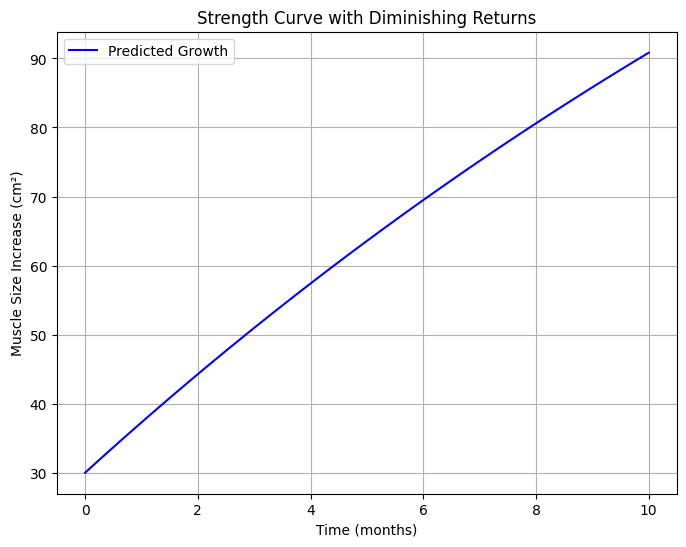

In [5]:
# Updated visualization to reflect the strength curve with current size
plt.figure(figsize=(8, 6))
x = np.linspace(0, 10, 100)  # Time in months
current_size = 30  # Example current size in cm
workout_time_years = 2  # Example workout time
age, gender, experience = 19, 'M', 'Advanced'
M_max, k = get_baseline_params(age, gender, experience, current_size, workout_time_years)
M0 = current_size * 0.2
growth_curve = M0 + (M_max - M0) * (1 - np.exp(-k * x))
plt.plot(x, growth_curve * 5, label='Predicted Growth', color='blue')  # Convert back to cm²
plt.xlabel('Time (months)')
plt.ylabel('Muscle Size Increase (cm²)')
plt.title('Strength Curve with Diminishing Returns')
plt.legend()
plt.grid(True)
plt.show()

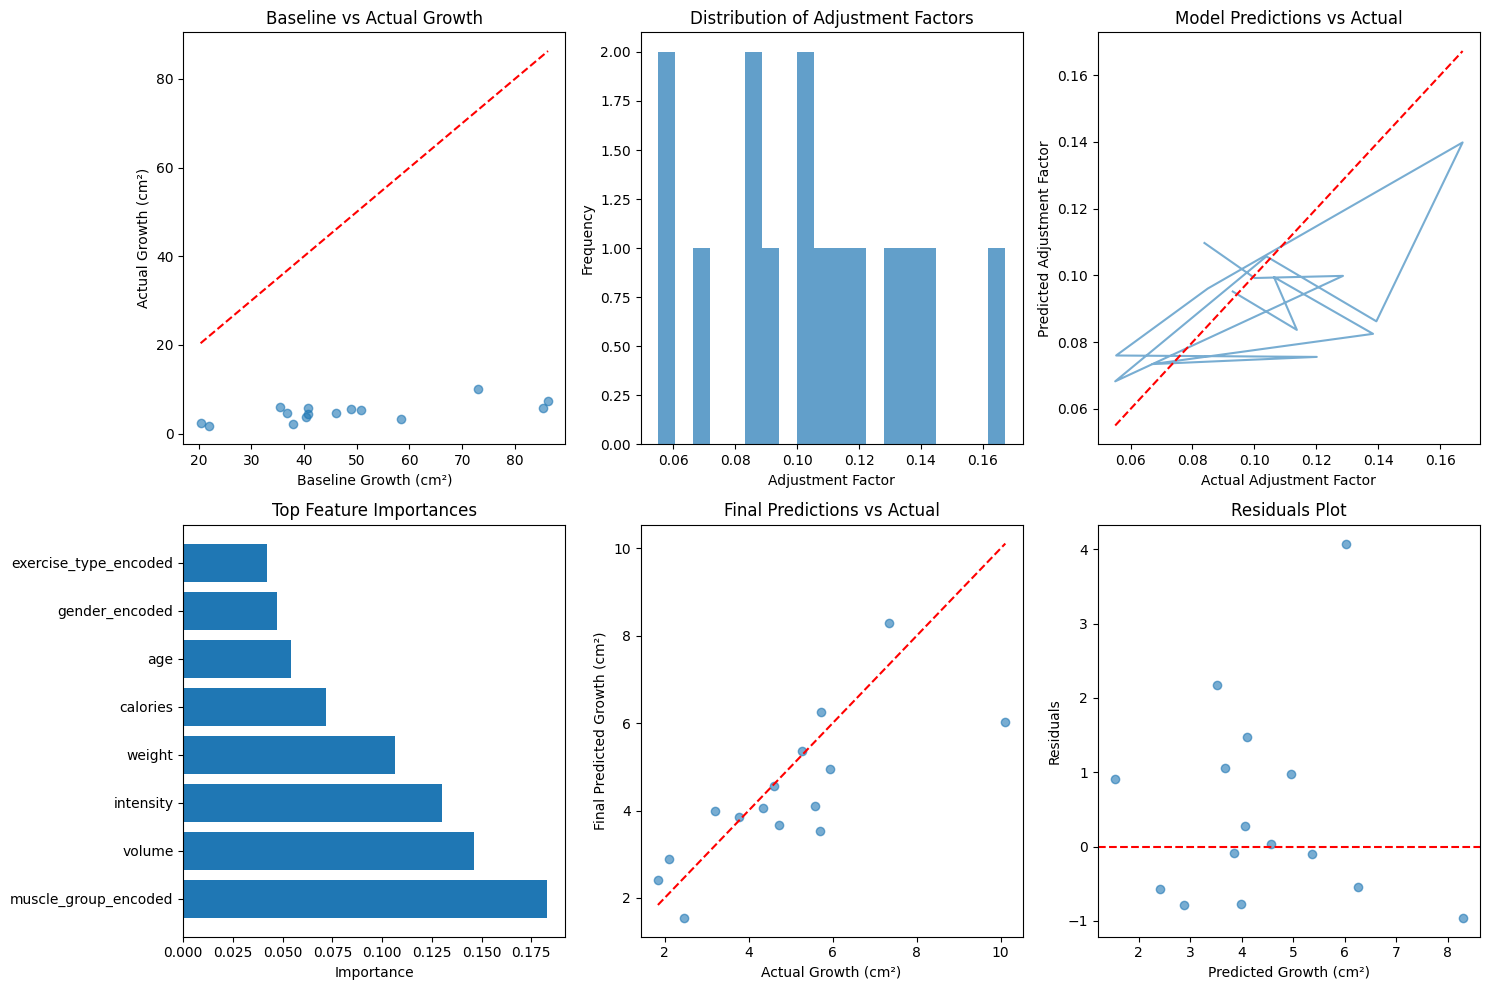


Model Training Complete!
The model learns to adjust the baseline muscle growth equation based on individual factors and current size.
Use the predict_muscle_growth() function to make new predictions.


In [6]:
# Visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Baseline vs Actual
plt.subplot(2, 3, 1)
plt.scatter(df['baseline_growth'], df['muscle_size_increase_cm2'], alpha=0.6)
plt.plot([df['baseline_growth'].min(), df['baseline_growth'].max()],
         [df['baseline_growth'].min(), df['baseline_growth'].max()], 'r--')
plt.xlabel('Baseline Growth (cm²)')
plt.ylabel('Actual Growth (cm²)')
plt.title('Baseline vs Actual Growth')

# Plot 2: Adjustment factors
plt.subplot(2, 3, 2)
plt.hist(df['adjustment_factor'], bins=20, alpha=0.7)
plt.xlabel('Adjustment Factor')
plt.ylabel('Frequency')
plt.title('Distribution of Adjustment Factors')

# Plot 3: Predicted vs Actual
plt.subplot(2, 3, 3)
y_pred_full = rf_model.predict(X)
plt.plot(y, y_pred_full, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Adjustment Factor')
plt.ylabel('Predicted Adjustment Factor')
plt.title('Model Predictions vs Actual')

# Plot 4: Feature importance
plt.subplot(2, 3, 4)
top_features = feature_importance.head(8)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top Feature Importances')

# Plot 5: Final predictions
plt.subplot(2, 3, 5)
final_predictions = df['baseline_growth'] * y_pred_full
plt.scatter(df['muscle_size_increase_cm2'], final_predictions, alpha=0.6)
plt.plot([df['muscle_size_increase_cm2'].min(), df['muscle_size_increase_cm2'].max()],
         [df['muscle_size_increase_cm2'].min(), df['muscle_size_increase_cm2'].max()], 'r--')
plt.xlabel('Actual Growth (cm²)')
plt.ylabel('Final Predicted Growth (cm²)')
plt.title('Final Predictions vs Actual')

# Plot 6: Residuals
plt.subplot(2, 3, 6)
residuals = df['muscle_size_increase_cm2'] - final_predictions
plt.scatter(final_predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Growth (cm²)')
plt.ylabel('Residuals')
plt.title('Residuals Plot')

plt.tight_layout()
plt.show()

print("\nModel Training Complete!")
print("The model learns to adjust the baseline muscle growth equation based on individual factors and current size.")
print("Use the predict_muscle_growth() function to make new predictions.")